# Projet de détection de fraude à l’assurance automobile

C'est un projet de détection de fraudes dans les demandes d’indemnisation liées à l’assurance automobile.

Le dataset utilisé contient des informations relatives :
- aux assurés,
- aux véhicules,
- aux contrats d’assurance, 
- ainsi qu’aux déclarations de sinistre.

A partir de ces données d'entrée, on determine si la demande est fraudulause ou pas.

Donc, l’objectif est de construire un pipeline complet de Machine Learning capable de prédire si une demande d’indemnisation est frauduleuse ou non.

On  est face à un problème de classification binaire :
- `0` : demande non frauduleuse ;
- `1` : demande frauduleuse.

## Import des librairies

In [27]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import  LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, GridSearchCV

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve

## Chargement du dataset



In [2]:
import os

print(os.getcwd())

/Users/alibahabakar/Projects/insurance-fraud-detection/notebook


In [3]:
path = "../input/fraud_oracle.csv"
df = pd.read_csv(path)



## Analyse exploratoire des données (EDA)

In [4]:
print("\nInformations sur les données:")
print(f" Shape : {df.shape}")
print("-"*70)
print(df.info())




Informations sur les données:
 Shape : (15420, 33)
----------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Month                 15420 non-null  str  
 1   WeekOfMonth           15420 non-null  int64
 2   DayOfWeek             15420 non-null  str  
 3   Make                  15420 non-null  str  
 4   AccidentArea          15420 non-null  str  
 5   DayOfWeekClaimed      15420 non-null  str  
 6   MonthClaimed          15420 non-null  str  
 7   WeekOfMonthClaimed    15420 non-null  int64
 8   Sex                   15420 non-null  str  
 9   MaritalStatus         15420 non-null  str  
 10  Age                   15420 non-null  int64
 11  Fault                 15420 non-null  str  
 12  PolicyType            15420 non-null  str  
 13  VehicleCategory       15420 non-null  s

In [5]:
print("\nStatistiques descriptives:")
print(df.describe())



Statistiques descriptives:
        WeekOfMonth  WeekOfMonthClaimed           Age  FraudFound_P  \
count  15420.000000        15420.000000  15420.000000  15420.000000   
mean       2.788586            2.693969     39.855707      0.059857   
std        1.287585            1.259115     13.492377      0.237230   
min        1.000000            1.000000      0.000000      0.000000   
25%        2.000000            2.000000     31.000000      0.000000   
50%        3.000000            3.000000     38.000000      0.000000   
75%        4.000000            4.000000     48.000000      0.000000   
max        5.000000            5.000000     80.000000      1.000000   

       PolicyNumber     RepNumber    Deductible  DriverRating          Year  
count  15420.000000  15420.000000  15420.000000  15420.000000  15420.000000  
mean    7710.500000      8.483268    407.704280      2.487808   1994.866472  
std     4451.514911      4.599948     43.950998      1.119453      0.803313  
min        1.000000 

### Valeurs manquantes ?

In [6]:
print("\nVérifier si présence de valeurs nulles:")
print(df.isna().sum().sum())

fraud_rate = df['FraudFound_P'].mean() * 100
print(f"Taux de fraude : {fraud_rate:.2f}%")
print(f"Taux de non fraude : {100 - fraud_rate:.2f}%")


Vérifier si présence de valeurs nulles:
0
Taux de fraude : 5.99%
Taux de non fraude : 94.01%


In [7]:

print(f"Colonnes: {list(df.columns)}")

num_colums = df.select_dtypes(include=np.number).columns.drop("FraudFound_P")
category_columns = df.select_dtypes(include=str).columns
print(f"Colonnes numériques: {list(num_colums)}")
print(f"Colonnes catégorielles: {list(category_columns)}")

df['FraudFound_P'].value_counts(normalize=True) * 100

Colonnes: ['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex', 'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'FraudFound_P', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year', 'BasePolicy']
Colonnes numériques: ['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Year']
Colonnes catégorielles: ['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', '

FraudFound_P
0    94.014267
1     5.985733
Name: proportion, dtype: float64

### Visualisation

/var/folders/r5/v0cjy_bn5c90xy_rgw6wkc5w0000gn/T/ipykernel_2182/1074836719.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='FraudFound_P', data=df, palette=["#23714F","#EB0784"])


Text(0, 0.5, 'Âge')

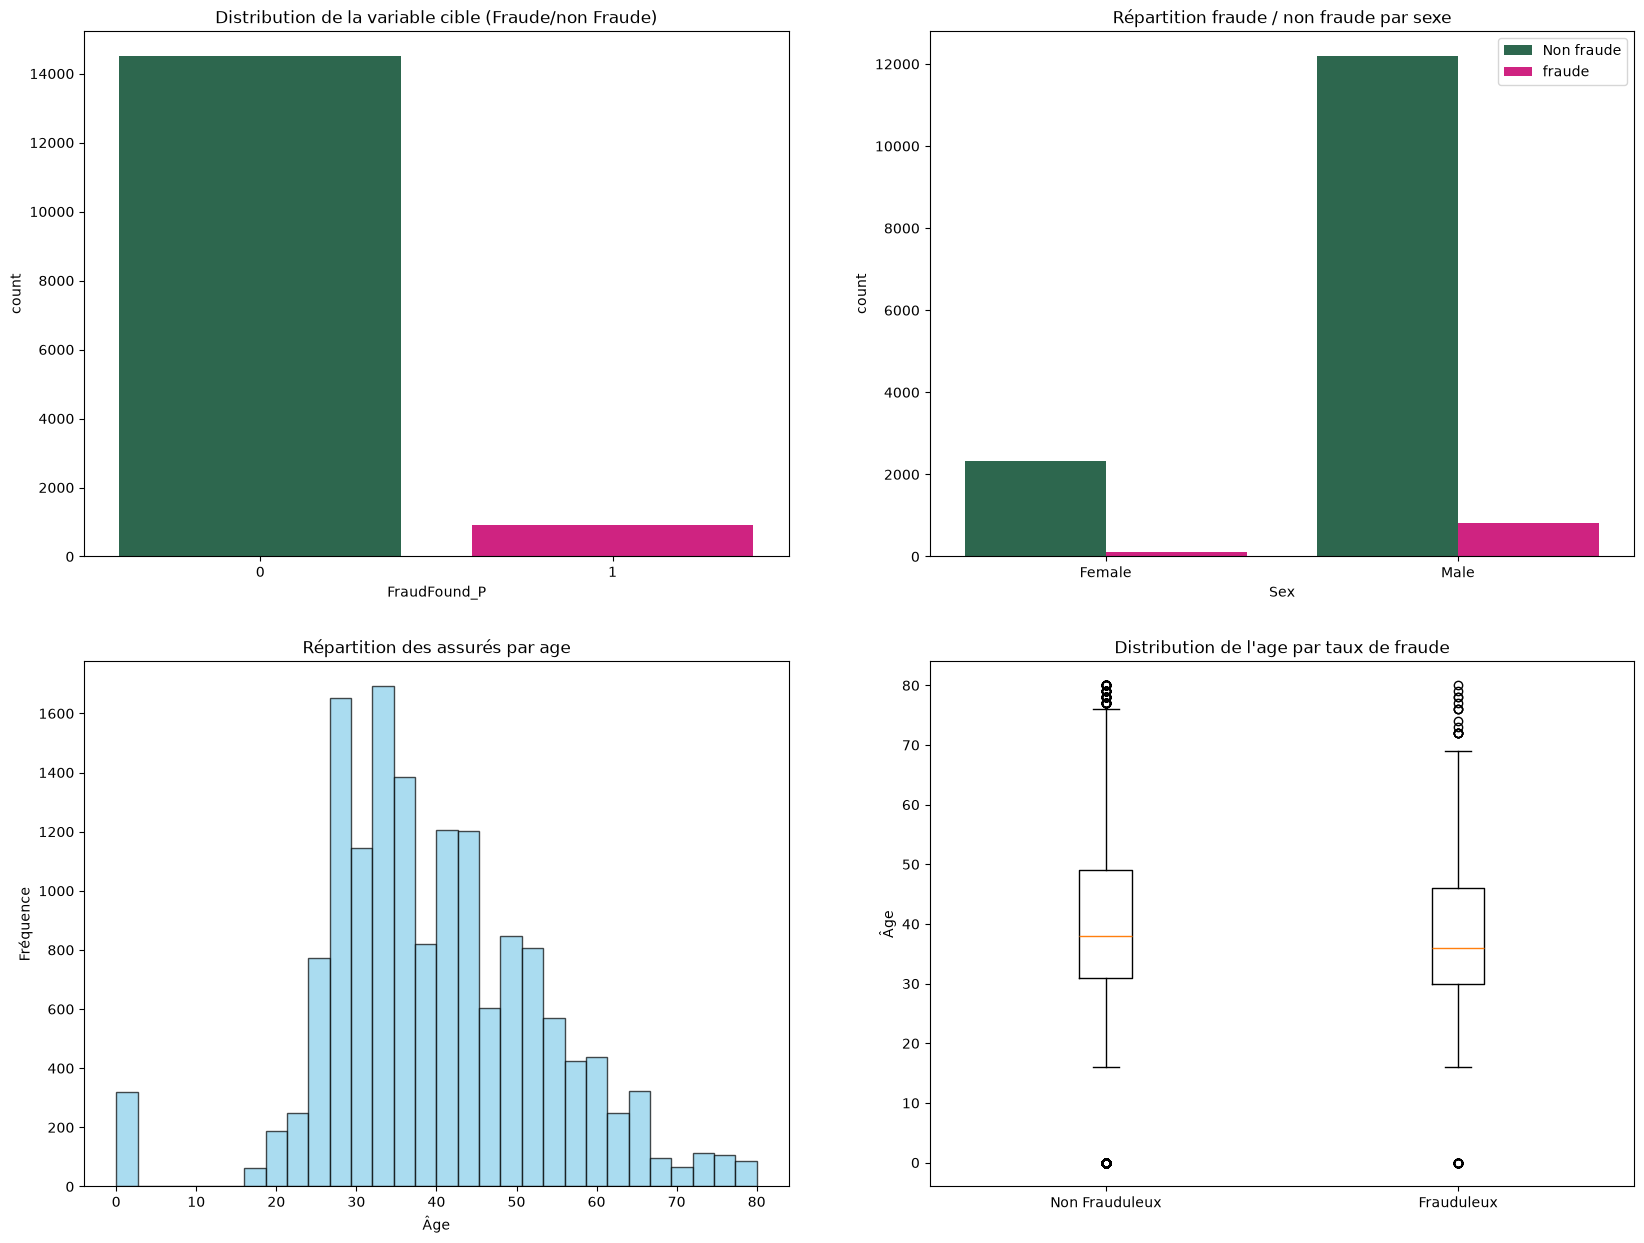

In [8]:
# EDA Visualisations
plt.figure(figsize=(20, 15))

# 1. Distribution de la variable cible
plt.subplot(2, 2, 1)
survival_counts = df['FraudFound_P'].value_counts()
sns.countplot(x='FraudFound_P', data=df, palette=["#23714F","#EB0784"])
plt.title('Distribution de la variable cible (Fraude/non Fraude)')

# 2. Taux de fraude par sexe
plt.subplot(2, 2, 2)
sns.countplot(x='Sex', hue='FraudFound_P',  data=df, palette=["#23714F","#EB0784"])
plt.title('Répartition fraude / non fraude par sexe')
plt.legend(['Non fraude', 'fraude'])
plt.xticks(rotation=0)


# 3. Distribution de l'âge
plt.subplot(2, 2, 3)
plt.hist(df['Age'].dropna(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Répartition des assurés par age')
plt.xlabel('Âge')
plt.ylabel('Fréquence')

# 4. Taux de fraude par âge (boxplot)
plt.subplot(2, 2, 4)
frauduleux_ages = df[df['FraudFound_P'] == 1]['Age'].dropna()
non_frauduleux_ages = df[df['FraudFound_P'] == 0]['Age'].dropna()
plt.boxplot([non_frauduleux_ages, frauduleux_ages], tick_labels=['Non Frauduleux', 'Frauduleux'])
plt.title("Distribution de l'age par taux de fraude")
plt.ylabel('Âge')







In [9]:
# Valeur age à 0
print(f"Nombre de lignes ou âge est à 0 : {(df["Age"] == 0).sum()} soit {round((df["Age"] == 0).sum() * 100 /df.shape[0], 2)} %")



Nombre de lignes ou âge est à 0 : 320 soit 2.08 %


La variable Age contient des valeurs égales à 0 (~2% du dataset).
On suppose que ces valeurs correspondent à des données manquantes. Pour le preprocessing, on choisit le mode d'imputation par la médiane plûtot que la moyenne afin de limiter l’impact des valeurs extrêmes sur la distribution.

## Liste des colonnes à supprimer
- PolicyNumber, RepNumber : qui sont des identifiants et unique et donc n'apportent pas d'information pour le projet de detection de fraude.

⚠️ Colonnes à surveiller et voir s'il faut supprimer après entrainement  
- PoliceReportFiled: rapport de police déposé (potentiellement déposé après l'accident)
- WitnessPresent: Présence de témoin
- NumberOfSuppliments: nombre de justificatifs supplémentaires
- Make: Marque des voitures- nombre de catégories très élevées (19) pour oneHotEncoder. Mais la marque peut impacter la fraude.

In [10]:
# verifier les features catégorielles
print(df[category_columns].nunique().sort_values(ascending=False))

for column in category_columns:
    print(f" {column} : {df[column].unique()}")
    print(f"________________________________")



Make                    19
MonthClaimed            13
Month                   12
AgeOfPolicyHolder        9
PolicyType               9
DayOfWeekClaimed         8
AgeOfVehicle             8
DayOfWeek                7
VehiclePrice             6
NumberOfCars             5
AddressChange_Claim      5
Days_Policy_Accident     5
Days_Policy_Claim        4
PastNumberOfClaims       4
MaritalStatus            4
NumberOfSuppliments      4
VehicleCategory          3
BasePolicy               3
Fault                    2
PoliceReportFiled        2
WitnessPresent           2
AgentType                2
Sex                      2
AccidentArea             2
dtype: int64
 Month : <StringArray>
['Dec', 'Jan', 'Oct', 'Jun', 'Feb', 'Nov', 'Apr', 'Mar', 'Aug', 'Jul', 'May',
 'Sep']
Length: 12, dtype: str
________________________________
 DayOfWeek : <StringArray>
['Wednesday', 'Friday', 'Saturday', 'Monday', 'Tuesday', 'Sunday', 'Thursday']
Length: 7, dtype: str
________________________________
 Make : <Stri

### Vérifier la corrélation de certaines variables catégorielles avec la target


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18]),
 [Text(0, 0, 'Mecedes'),
  Text(1, 0, 'Accura'),
  Text(2, 0, 'Saturn'),
  Text(3, 0, 'Saab'),
  Text(4, 0, 'Ford'),
  Text(5, 0, 'Mercury'),
  Text(6, 0, 'BMW'),
  Text(7, 0, 'Honda'),
  Text(8, 0, 'Toyota'),
  Text(9, 0, 'Chevrolet'),
  Text(10, 0, 'Pontiac'),
  Text(11, 0, 'Mazda'),
  Text(12, 0, 'Nisson'),
  Text(13, 0, 'VW'),
  Text(14, 0, 'Dodge'),
  Text(15, 0, 'Lexus'),
  Text(16, 0, 'Porche'),
  Text(17, 0, 'Jaguar'),
  Text(18, 0, 'Ferrari')])

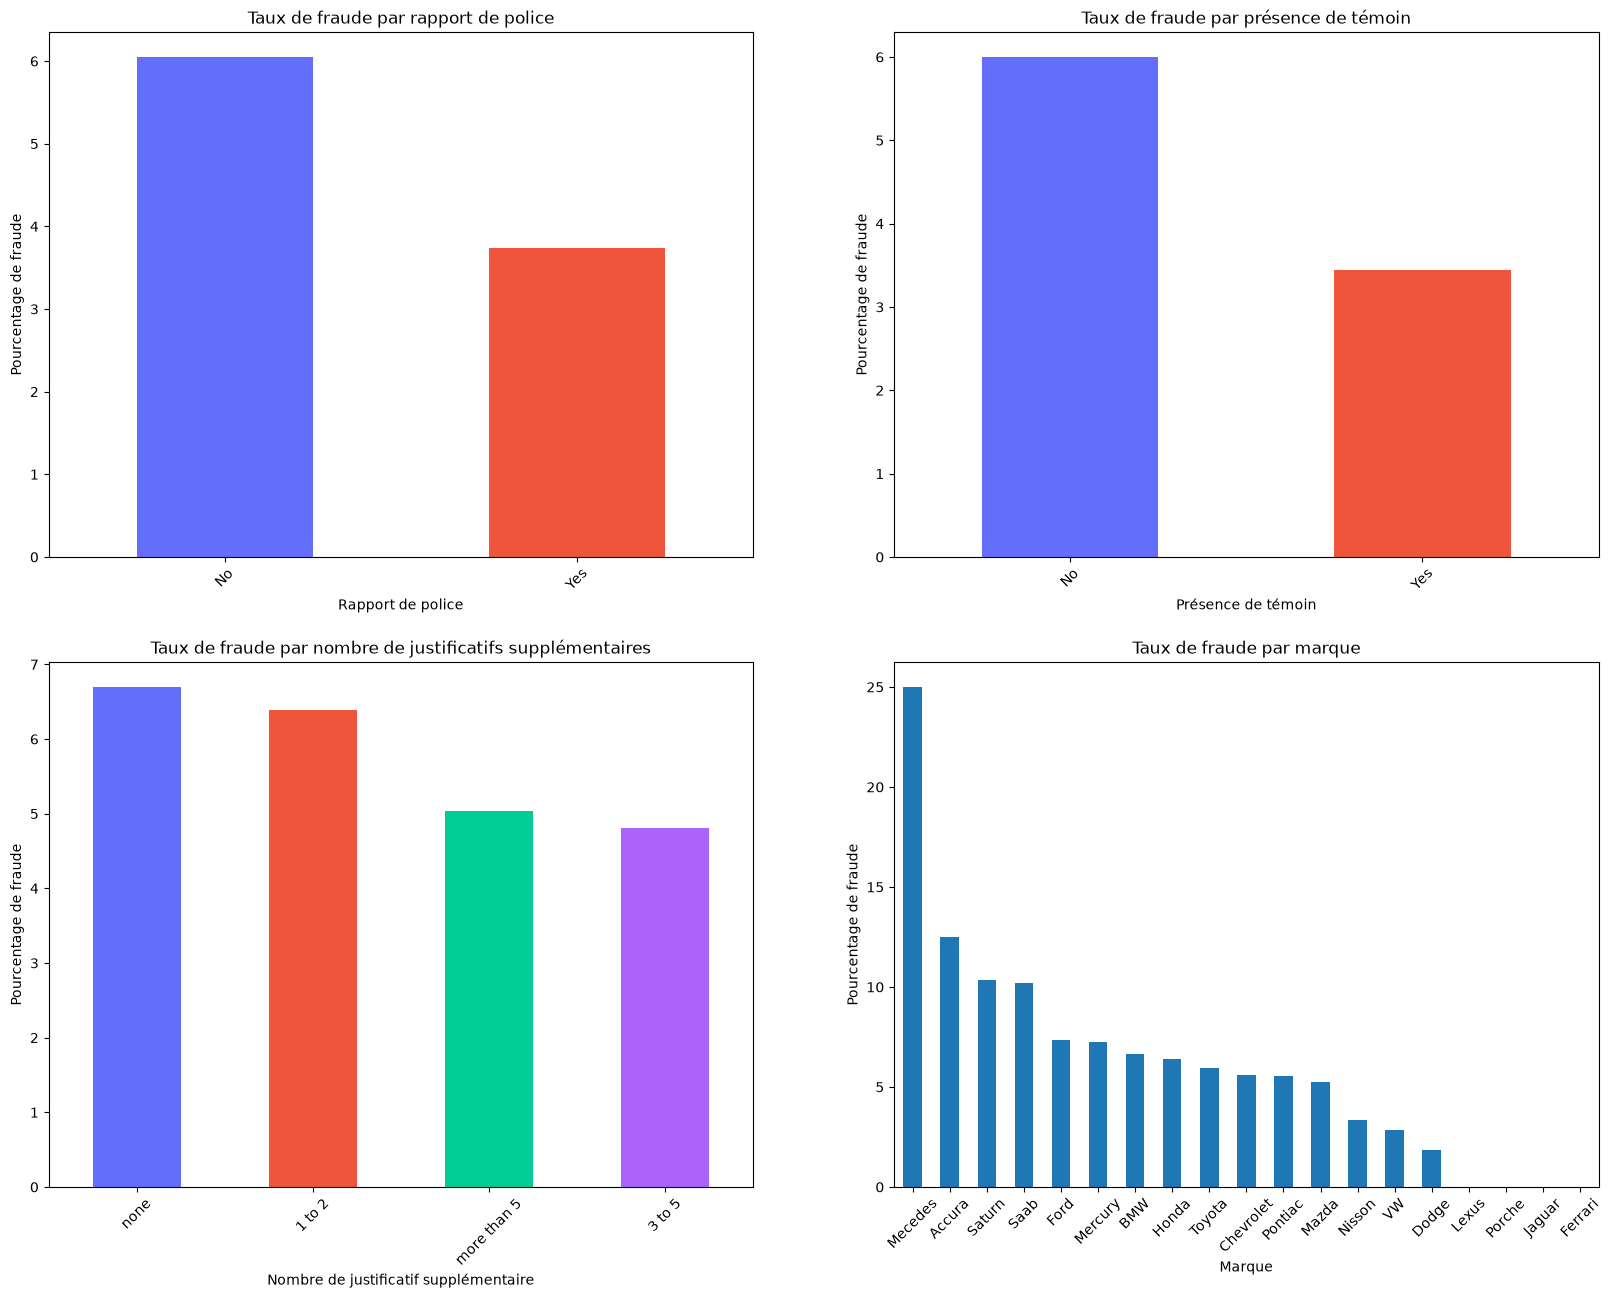

In [11]:
# PoliceReportFiled
plt.figure(figsize=(20, 15))

plt.subplot(2, 2, 1)
fraud_rate = (
    df.groupby("PoliceReportFiled")["FraudFound_P"]
    .mean()
    .sort_values(ascending=False)
    * 100
)
fraud_rate.plot(kind="bar",color= ['#636EFA', '#EF553B'])
plt.title("Taux de fraude par rapport de police")
plt.xlabel("Rapport de police")
plt.ylabel("Pourcentage de fraude")
plt.xticks(rotation=45)

# WitnessPresent

plt.subplot(2, 2, 2)
fraud_rate = (
    df.groupby("WitnessPresent")["FraudFound_P"]
    .mean()
    .sort_values(ascending=False)
    * 100
)
fraud_rate.plot(kind="bar", color= ['#636EFA', '#EF553B', ])
plt.title("Taux de fraude par présence de témoin")
plt.xlabel("Présence de témoin")
plt.ylabel("Pourcentage de fraude")
plt.xticks(rotation=45)

# NumberOfSuppliments
plt.subplot(2, 2, 3)
fraud_rate = (
    df.groupby("NumberOfSuppliments")["FraudFound_P"]
    .mean()
    .sort_values(ascending=False)
    * 100
)
fraud_rate.plot(kind="bar", color= ['#636EFA', '#EF553B',  '#00CC96', '#AB63FA'])
plt.title("Taux de fraude par nombre de justificatifs supplémentaires")
plt.xlabel("Nombre de justificatif supplémentaire")
plt.ylabel("Pourcentage de fraude")
plt.xticks(rotation=45)


plt.subplot(2, 2, 4)
fraud_rate = (
    df.groupby("Make")["FraudFound_P"]
    .mean()
    .sort_values(ascending=False)
    * 100
)
fraud_rate.plot(kind="bar")
plt.title("Taux de fraude par marque")
plt.xlabel("Marque")
plt.ylabel("Pourcentage de fraude")
plt.xticks(rotation=45)

## Split des données entrainement et de test

In [12]:
# Séparation label et features
X = df.drop(columns=["PolicyNumber", "RepNumber", "FraudFound_P"])
y = df["FraudFound_P"]


# Séparation des données d'entrainement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

num_colums = X_train.select_dtypes(include=np.number).columns
cat_colums = X_train.select_dtypes(include=str).columns

print(f"num_colums {len(num_colums)}")
print(f"cat_colums {len(cat_colums)}")
print(y_test.shape)
print(y_train.shape)


num_colums 6
cat_colums 24
(3084,)
(12336,)


## Utilisation des pipelines pour le preprocessing

### Liste des colonnes

In [13]:
numeric_columns = ['WeekOfMonth', 'WeekOfMonthClaimed', 'Deductible', 'DriverRating', 'Year']
age_column = ['Age'] # Imputer special pour age
make_column = ["Make"]
categoric_one_hot_columns = ["AccidentArea", "Sex", "MaritalStatus", "Fault", "PolicyType", 
                             "VehicleCategory", "AgentType", "BasePolicy","PoliceReportFiled","WitnessPresent"]
categoric_ordinal_columns = ["NumberOfCars", "VehiclePrice", "Days_Policy_Claim", 
                    "Days_Policy_Accident", "PastNumberOfClaims", "AgeOfVehicle", 
                    "AgeOfPolicyHolder", "AddressChange_Claim", "Month", "DayOfWeek", "DayOfWeekClaimed", "MonthClaimed", "NumberOfSuppliments"]



### Pipeline pour les colonnes numériques

In [14]:
numeric_pipe = Pipeline(steps=[('imputer', SimpleImputer()),('scaler', StandardScaler())])
age_numeric_pipe = Pipeline(steps=[('imputer', SimpleImputer(missing_values=0, strategy='median')),('scaler', StandardScaler()) ])


### Pipeline pour l'encodage des variables catégorielles


In [15]:

#OrdinalEncoder

NumberOfCars_order = ['1 vehicle', '2 vehicles', '3 to 4', '5 to 8', 'more than 8']
VehiclePrice_order = ['less than 20000','20000 to 29000', '30000 to 39000', '40000 to 59000', '60000 to 69000','more than 69000']
Days_Policy_Claim_order= ['none', '8 to 15', '15 to 30','more than 30' ]
Days_Policy_Accident_order= ['none', '1 to 7','8 to 15', '15 to 30','more than 30' ]
PastNumberOfClaims_order= ['none', '1', '2 to 4', 'more than 4']
AgeOfVehicle_order= [ 'new',   '2 years', '3 years', '4 years',  '5 years',  '6 years',     '7 years', 'more than 7'  ]
AgeOfPolicyHolder_order= ['16 to 17','18 to 20', '21 to 25','26 to 30', '31 to 35','36 to 40', '41 to 50', '51 to 65','over 65']
AddressChange_Claim_order= ['no change', 'under 6 months', '1 year', '2 to 3 years', '4 to 8 years']
Month_order= ['Jan', 'Feb', 'Mar','Apr', 'May','Jun','Jul', 'Aug','Sep','Oct', 'Nov','Dec' ]
DayOfWeek_order= ['Sunday','Monday','Tuesday', 'Wednesday', 'Thursday','Friday', 'Saturday' ]
DayOfWeekClaimed_order= ['0', 'Sunday','Monday','Tuesday', 'Wednesday', 'Thursday','Friday', 'Saturday' ]
MonthClaimed_order= ['0', 'Jan', 'Feb', 'Mar','Apr', 'May','Jun','Jul', 'Aug','Sep','Oct', 'Nov','Dec' ]
NumberOfSuppliments_order = ['none','1 to 2', '3 to 5','more than 5'  ]


ordinal_encoder_pipe = Pipeline([ ('imputer', SimpleImputer(strategy='most_frequent')),
                                   ("encoder", OrdinalEncoder(
            categories=[
                NumberOfCars_order, 
                VehiclePrice_order, 
                Days_Policy_Claim_order,
                Days_Policy_Accident_order,
                PastNumberOfClaims_order,
                AgeOfVehicle_order,
                AgeOfPolicyHolder_order,
                AddressChange_Claim_order,
                Month_order,
                DayOfWeek_order,
                DayOfWeekClaimed_order,
                MonthClaimed_order,
                NumberOfSuppliments_order
            ]
        )
    ) 
])

#OneHotEncoder
categoric_one_hot_pipe = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore')) ])

# Target encoder
make_categoric_pipe = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),('encoder', TargetEncoder(target_type="auto")) ])

### Utilisation du columnTranformer

In [16]:
preprocessor = ColumnTransformer([
    
    ("num", numeric_pipe, numeric_columns),

    ("age", age_numeric_pipe, age_column),


    ("onehot", categoric_one_hot_pipe, categoric_one_hot_columns),

    ("ordinale", ordinal_encoder_pipe, categoric_ordinal_columns),

    ("make", make_categoric_pipe, make_column)
])

## Modèle Baseline
La régression logistique est utilisée comme baseline car elle fournit un modèle rapide et interprétable pour une tâche de classification binaire. Elle permet d’établir un premier niveau de performance avant de comparer des modèles plus complexes capables de capturer des relations non linéaires.

In [32]:
# Regression Logistique

print("\nCréation du pipeline avec préprocessing et modèle...")
pipeline_logReg = Pipeline([
    ('preprocessor', preprocessor),                  
    ('logistic', LogisticRegression(class_weight='balanced', max_iter=1000))              # Modèle de régression logistique
])



# Entrainement et prédiction du modèle
pipeline_logReg.fit(X_train, y_train)
y_pred = pipeline_logReg.predict(X_test)

# probabilities
y_prob = pipeline_logReg.predict_proba(X_test)[:, 1]

# evaluation
print(classification_report(y_test, y_pred))







Création du pipeline avec préprocessing et modèle...
              precision    recall  f1-score   support

           0       0.99      0.60      0.74      2899
           1       0.13      0.91      0.22       185

    accuracy                           0.61      3084
   macro avg       0.56      0.75      0.48      3084
weighted avg       0.94      0.61      0.71      3084



## Modele RandomForest

In [ ]:
# Modele RandomForest
print("\nCréation du pipeline avec préprocessing et modèle...")


random_preprocessor = ColumnTransformer([
    
   ("num", Pipeline(steps=[('imputer', SimpleImputer())]), numeric_columns),

   ("age", age_numeric_pipe, age_column),
    
    ("onehot", categoric_one_hot_pipe, categoric_one_hot_columns),

    ("ordinale", ordinal_encoder_pipe, categoric_ordinal_columns),
    
    ("make", make_categoric_pipe, make_column)
])

pipeline_random = Pipeline([
    ('preprocessor', random_preprocessor),                  # Proprcessor
    ('random', RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=200,))              # Modèle de foret aléatoire
])

# Entrainement et prédiction du modèle
pipeline_random.fit(X_train, y_train)
y_pred = pipeline_random.predict(X_test)

# probabilities
y_prob = pipeline_random.predict_proba(X_test)[:, 1]

# evaluation
print(classification_report(y_test, y_pred))


# Ne détecte pratiquement pas les cas de fraude. Car le recall est de 0.01 => Detecte 2 cas de fraude sur 185
# Donc risque de ne pas retenir ce modèle. Pour les cas de ce type de fraude , c'est probalement très couteux de
# ne pas detecter les fraudes. Donc un modèle qui detecte mieux les fraudes est préférables dans notre cas.


Création du pipeline avec préprocessing et modèle...
              precision    recall  f1-score   support

           0       0.94      0.99      0.97      2899
           1       0.34      0.08      0.12       185

    accuracy                           0.94      3084
   macro avg       0.64      0.53      0.55      3084
weighted avg       0.91      0.94      0.92      3084



## Modèle Boost
Modèle utilise est CatBoost car le dataset contient beaucoup de features catégorielles

In [ ]:
# Modele XGBoost
print("\nCréation du pipeline avec préprocessing et modèle CatBoost...")


boost_preprocessor = ColumnTransformer([
    
   ("num", Pipeline(steps=[('imputer', SimpleImputer())]), numeric_columns),

   ("age", age_numeric_pipe, age_column),
    
    ("onehot", categoric_one_hot_pipe, categoric_one_hot_columns),

    ("ordinale", ordinal_encoder_pipe, categoric_ordinal_columns),

    ("make", make_categoric_pipe, make_column)
])

pipeline_boost = Pipeline([
    ('preprocessor', boost_preprocessor),                  # Proprcessor
    ('boosting', CatBoostClassifier(iterations=100, auto_class_weights='Balanced'))              # Modèle Boost
])

# Entrainement et prédiction du modèle
pipeline_boost.fit(X_train, y_train)
y_pred = pipeline_boost.predict(X_test)

# probabilities
y_prob = pipeline_boost.predict_proba(X_test)[:, 1]

# evaluation
print(classification_report(y_test, y_pred))



Création du pipeline avec préprocessing et modèle CatBoost...
Learning rate set to 0.248809
0:	learn: 0.5764420	total: 2.63ms	remaining: 260ms
1:	learn: 0.5273735	total: 4.64ms	remaining: 227ms
2:	learn: 0.5073684	total: 6.57ms	remaining: 213ms
3:	learn: 0.4941115	total: 9.33ms	remaining: 224ms
4:	learn: 0.4789924	total: 11.4ms	remaining: 216ms
5:	learn: 0.4724491	total: 14.1ms	remaining: 221ms
6:	learn: 0.4677752	total: 16.9ms	remaining: 224ms
7:	learn: 0.4619099	total: 18.9ms	remaining: 217ms
8:	learn: 0.4592006	total: 21.2ms	remaining: 214ms
9:	learn: 0.4504010	total: 23.5ms	remaining: 211ms
10:	learn: 0.4461290	total: 25.7ms	remaining: 208ms
11:	learn: 0.4435080	total: 27.6ms	remaining: 203ms
12:	learn: 0.4419828	total: 29.9ms	remaining: 200ms
13:	learn: 0.4380994	total: 31.9ms	remaining: 196ms
14:	learn: 0.4296911	total: 34.2ms	remaining: 194ms
15:	learn: 0.4268993	total: 36.3ms	remaining: 190ms
16:	learn: 0.4094020	total: 38.6ms	remaining: 188ms
17:	learn: 0.4054720	total: 41.3m

Après une première phase d’évaluation, deux modèles ont été retenus pour approfondissement : Logistic Regression et CatBoost. Ces modèles présentent les meilleurs résultats sur la classe minoritaire (fraude). Une phase de tuning est ensuite réalisée afin d’évaluer leur potentiel réel et d’identifier le meilleur compromis entre détection des fraudes et limitation des faux positifs.

- GridSearchCV : teste toutes les combinaisons

- RandomizedSearchCV : teste un nombre limité de combinaisons aléatoires - si la grille est trop grande

In [20]:
# GridSearchCV sur moèle RegressionLogistic

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
params = {
    'logistic__C': [0.01, 0.1, 1, 10, 100],
}

print(pipeline_logReg.get_params().keys())
logRegSearch = GridSearchCV(pipeline_logReg, param_grid=params, cv=cv, scoring='roc_auc', n_jobs=-1)
logRegSearch.fit(X_train, y_train)
print(f"Best parameters: {logRegSearch.best_params_}")

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'preprocessor', 'logistic', 'preprocessor__n_jobs', 'preprocessor__remainder', 'preprocessor__sparse_threshold', 'preprocessor__transformer_weights', 'preprocessor__transformers', 'preprocessor__verbose', 'preprocessor__verbose_feature_names_out', 'preprocessor__num', 'preprocessor__age', 'preprocessor__onehot', 'preprocessor__ordinale', 'preprocessor__make', 'preprocessor__num__memory', 'preprocessor__num__steps', 'preprocessor__num__transform_input', 'preprocessor__num__verbose', 'preprocessor__num__imputer', 'preprocessor__num__scaler', 'preprocessor__num__imputer__add_indicator', 'preprocessor__num__imputer__copy', 'preprocessor__num__imputer__fill_value', 'preprocessor__num__imputer__keep_empty_features', 'preprocessor__num__imputer__missing_values', 'preprocessor__num__imputer__strategy', 'preprocessor__num__scaler__copy', 'preprocessor__num__scaler__with_mean', 'preprocessor__num__scaler__with_std', 'preprocessor__age__

In [21]:
# RandomizedSearchCV sur moèle RandomForest

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
params = {
    'random__n_estimators': [10, 50, 100],
    'random__max_depth': [None, 10, 20, 50],
    'random__max_features': [2, 5],
    'random__min_samples_leaf': [1, 2, 4]
}

print(pipeline_random.get_params().keys())
randomSearch = RandomizedSearchCV(pipeline_random, param_distributions=params, n_iter=30, cv=cv, scoring='roc_auc', n_jobs=-1,  random_state=42)
#randomSearch = GridSearchCV(pipeline_random, param_grid=parms, cv=cv, scoring='roc_auc', n_jobs=-1)
randomSearch.fit(X_train, y_train)
print(f"Best parameters: {randomSearch.best_params_}")

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'preprocessor', 'random', 'preprocessor__n_jobs', 'preprocessor__remainder', 'preprocessor__sparse_threshold', 'preprocessor__transformer_weights', 'preprocessor__transformers', 'preprocessor__verbose', 'preprocessor__verbose_feature_names_out', 'preprocessor__num', 'preprocessor__age', 'preprocessor__onehot', 'preprocessor__ordinale', 'preprocessor__make', 'preprocessor__num__memory', 'preprocessor__num__steps', 'preprocessor__num__transform_input', 'preprocessor__num__verbose', 'preprocessor__num__imputer', 'preprocessor__num__imputer__add_indicator', 'preprocessor__num__imputer__copy', 'preprocessor__num__imputer__fill_value', 'preprocessor__num__imputer__keep_empty_features', 'preprocessor__num__imputer__missing_values', 'preprocessor__num__imputer__strategy', 'preprocessor__age__memory', 'preprocessor__age__steps', 'preprocessor__age__transform_input', 'preprocessor__age__verbose', 'preprocessor__age__imputer', 'preproces

In [22]:
# RandomizedSearchCV sur moèle CatBoost

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
params = {
    'boosting__depth': [4,5,6,7,8,9, 10],
    'boosting__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'boosting__iterations': [10, 20,30,40,50,60,70,80,90, 100]
}

print(pipeline_boost.get_params().keys())
boostingSearch = RandomizedSearchCV(pipeline_boost, param_distributions=params, cv=cv, n_iter=30,scoring='roc_auc', n_jobs=-1, random_state=42)
boostingSearch.fit(X_train, y_train)
print(f"Best parameters: {boostingSearch.best_params_}")

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'preprocessor', 'boosting', 'preprocessor__n_jobs', 'preprocessor__remainder', 'preprocessor__sparse_threshold', 'preprocessor__transformer_weights', 'preprocessor__transformers', 'preprocessor__verbose', 'preprocessor__verbose_feature_names_out', 'preprocessor__num', 'preprocessor__age', 'preprocessor__onehot', 'preprocessor__ordinale', 'preprocessor__make', 'preprocessor__num__memory', 'preprocessor__num__steps', 'preprocessor__num__transform_input', 'preprocessor__num__verbose', 'preprocessor__num__imputer', 'preprocessor__num__imputer__add_indicator', 'preprocessor__num__imputer__copy', 'preprocessor__num__imputer__fill_value', 'preprocessor__num__imputer__keep_empty_features', 'preprocessor__num__imputer__missing_values', 'preprocessor__num__imputer__strategy', 'preprocessor__age__memory', 'preprocessor__age__steps', 'preprocessor__age__transform_input', 'preprocessor__age__verbose', 'preprocessor__age__imputer', 'preproc

/Users/alibahabakar/Projects/insurance-fraud-detection/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


29:	learn: 0.4226532	total: 128ms	remaining: 299ms
33:	learn: 0.4179720	total: 166ms	remaining: 323ms
30:	learn: 0.4203778	total: 131ms	remaining: 291ms
28:	learn: 0.4170377	total: 160ms	remaining: 393ms
39:	learn: 0.4058026	total: 187ms	remaining: 281ms
34:	learn: 0.4111265	total: 169ms	remaining: 314ms
31:	learn: 0.4188030	total: 133ms	remaining: 282ms
35:	learn: 0.4097125	total: 172ms	remaining: 306ms
32:	learn: 0.4179969	total: 135ms	remaining: 275ms
40:	learn: 0.4046596	total: 191ms	remaining: 275ms
29:	learn: 0.4153662	total: 165ms	remaining: 385ms
33:	learn: 0.4168652	total: 139ms	remaining: 271ms
41:	learn: 0.4023692	total: 195ms	remaining: 270ms
30:	learn: 0.4122846	total: 169ms	remaining: 377ms
36:	learn: 0.4092248	total: 178ms	remaining: 302ms
34:	learn: 0.4156948	total: 144ms	remaining: 267ms
31:	learn: 0.4105228	total: 173ms	remaining: 368ms
42:	learn: 0.4000733	total: 200ms	remaining: 265ms
37:	learn: 0.4068621	total: 182ms	remaining: 297ms
35:	learn: 0.4134743	total: 146

## Choisir le meilleur modèle

In [35]:
best_logreg = logRegSearch.best_estimator_
best_boost = boostingSearch.best_estimator_

models = {
    "Logistic Regression": best_logreg,
    "CatBoost" : best_boost
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

df_results = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
print(df_results)






                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
1             CatBoost  0.682555   0.152972  0.945946  0.263356  0.861408
0  Logistic Regression  0.612192   0.124722  0.908108  0.219321  0.801779


## Conclusion

- Après optimisation des hyperparamètres, CatBoost devient le modèle le plus performant. 
- Il obtient le meilleur Recall (94.1 %), le meilleur F1-score (0.260) ainsi que le meilleur ROC-AUC (0.857). Ces résultats indiquent que CatBoost est plus efficace pour détecter les cas de fraude.
- CatBoost offre donc ici le meilleur compromis, avec 59 % de recall, 20 % de precision et le meilleur F1 de la classe 1 à 0,30